# Cumulative Regret Comparison
## Classic ACL vs Classic cUCB vs Quantum CBO (cUCB) vs Classic BO (WGP-UCB)
Compare cumulative regret at two noise levels ($\sigma^2=0.01$ and $\sigma^2=0.04$) in **one** figure.  


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from os import path
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data directories ----
classic_bo_dir   = 'Experiments/Classic_Discrete/exp_set_1/'
quantum_cbo_dir  = 'Experiments_constraints/Quantum_Discrete_cUCB/exp_set_1/'
quantum_cbo_real_dir  = 'Experiments_constraints/Quantum_Discrete_cUCB_Real/exp_set_0/'
classic_acl_dir  = 'Experiments_constraints/Classic_ACL_Discrete/exp_set_0/'
classic_cbo_dir  = 'Experiments_constraints/Classic_Discrete_cUCB/exp_set_1/'
classic_unconstrained_dir = 'Experiments_constraints/Classic_Discrete_Unconstrained/exp_set_1/'
# ---- Optimal value ----
f_max = 0.048170337104871036

# ---- Noise levels ----
noise_levels = [0.1**2, 0.2**2]

# ---- Trials ----
n_trials = 5
run_list = np.arange(n_trials)

MAX_BUDGET = int(6000 + 100)
X_LIM = 5000

print(f"Device : {device}")
print(f"f_max  : {f_max}")
print(f"Noise  : {noise_levels}")

Device : cuda
f_max  : 0.048170337104871036
Noise  : [0.010000000000000002, 0.04000000000000001]


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from os import path
import os


def load_data(filename, device):
    data = torch.load(filename, map_location=device, weights_only=False)
    actions        = data['actions'].to(torch.float32).to(device)
    response       = data['response'].to(torch.float32).to(device)
    true_response  = data['true_response'].to(torch.float32).to(device)
    num_of_queries = data['queries']
    eps            = data['uncertainty']
    return actions, true_response, response, num_of_queries, eps


def compute_cumulative_regret(true_response, num_of_queries, f_max):
    """
    Follow analyze_discrete.ipynb exactly:
      - x-axis = total oracle samples (each queried point i is repeated q[i] times)
      - instantaneous regret = |f_max - true_response[i]|  (same as analyze_discrete)
    If queries[i] == 0 (as in Q-cUCB-Real files), treat as 1 oracle call per point.
    """
    values        = true_response.detach().cpu().numpy()
    track_queries = num_of_queries.detach().cpu().numpy().astype(np.int32)

    values_new = []
    for i in range(len(values)):
        if track_queries[i] > 0:  # skip zero-query rows (IAE overhead, not oracle calls)
            values_new += list(np.repeat(values[i], track_queries[i]))

    values_new = np.array(values_new)
    instantaneous     = np.squeeze(np.abs(f_max - values_new))
    cumulative_regret = np.cumsum(instantaneous)
    return cumulative_regret


def plot_mean_and_CI(ax, time_steps, mean, lb, ub,
                     color=None, marker=None, marker_size=8,
                     markevery=500, label=None, linestyle='-'):
    ax.fill_between(time_steps, ub, lb, color=color, alpha=0.15)
    line, = ax.plot(time_steps, mean, color=color,
                    marker=marker, markersize=marker_size,
                    markevery=markevery, label=label,
                    linestyle=linestyle, linewidth=2)
    return line


In [7]:
# ---- Method configurations ----

methods = {
    'C-WGP-UCB': {
        'dir': classic_bo_dir,
        'pattern': '{noise}training_data_{trial}_.pth',
        'colors': {0.1**2: 'red', 0.2**2: 'orange'},
        'marker': 's',
    },
    'Q-cUCB': {
        'dir': quantum_cbo_dir,
        'pattern': '{noise}quan_training_data_{trial}_.pth',
        'colors': {0.1**2: 'blue', 0.2**2: 'purple'},
        'marker': 'v',
    },
    'Q-cUCB-Real': {
        'dir': quantum_cbo_real_dir,
        'pattern': '{noise}quan_training_data_{trial}_.pth',
        'colors': {0.1**2: 'm', 0.2**2: 'indigo'},
        'marker': '^',
    },
    'C-cUCB': {
        'dir': classic_cbo_dir,
        'pattern': '{noise}training_data_{trial}_.pth',
        'colors': {0.1**2: '#2196F3', 0.2**2: '#03A9F4'},
        'marker': 'o',
    },
    'C-ACL': {
        'dir': classic_acl_dir,
        'pattern': '{noise}acl_training_data_{trial}_.pth',
        'colors': {0.1**2: 'green', 0.2**2: 'darkcyan'},
        'marker': 'D',
    },
    'C-Unconstrained': {
        'dir': classic_unconstrained_dir,
        'pattern': '{noise}training_data_{trial}_.pth',
        'colors': {0.1**2: 'grey', 0.2**2: 'black'},
        'marker': 'x',
    },
}

# ---- Collect results ----
results = {}

for noise in noise_levels:
    noise_str = str(noise)
    results[noise] = {}

    for mname, cfg in methods.items():
        all_regrets = []
        min_len = MAX_BUDGET

        for trial in run_list:
            fpath = os.path.join(cfg['dir'],
                                 cfg['pattern'].format(noise=noise_str, trial=trial))
            if not os.path.exists(fpath):
                continue

            try:
                _, true_resp, _, nq, _ = load_data(fpath, device)
                cr = compute_cumulative_regret(true_resp, nq, f_max)
                min_len = min(min_len, len(cr))
                all_regrets.append(cr)
            except Exception as exc:
                print(f"[WARN] {fpath}: {exc}")

        if all_regrets:
            all_regrets = [a[:min_len] for a in all_regrets]
            arr    = np.array(all_regrets)
            mean   = arr.mean(axis=0)
            stderr = arr.std(axis=0) / np.sqrt(len(all_regrets))
            results[noise][mname] = dict(
                mean=mean, ub=mean+stderr, lb=mean-stderr,
                min_len=min_len, n_trials=len(all_regrets))
            sigma = np.sqrt(noise)
            print(f"  {mname:16s}  sigma={sigma:.1f}  "
                  f"trials={len(all_regrets)}  steps={min_len}")
        else:
            sigma = np.sqrt(noise)
            print(f"  {mname:16s}  sigma={sigma:.1f}  ** NO DATA **")


  C-WGP-UCB         sigma=0.1  trials=5  steps=6100
  Q-cUCB            sigma=0.1  trials=5  steps=6100
  Q-cUCB-Real       sigma=0.1  ** NO DATA **
  C-cUCB            sigma=0.1  trials=5  steps=6070
  C-ACL             sigma=0.1  trials=5  steps=5010
  C-WGP-UCB         sigma=0.2  trials=5  steps=6100
  Q-cUCB            sigma=0.2  trials=5  steps=6100
  Q-cUCB-Real       sigma=0.2  trials=1  steps=6100
  C-cUCB            sigma=0.2  trials=5  steps=6100
  C-ACL             sigma=0.2  trials=5  steps=5010


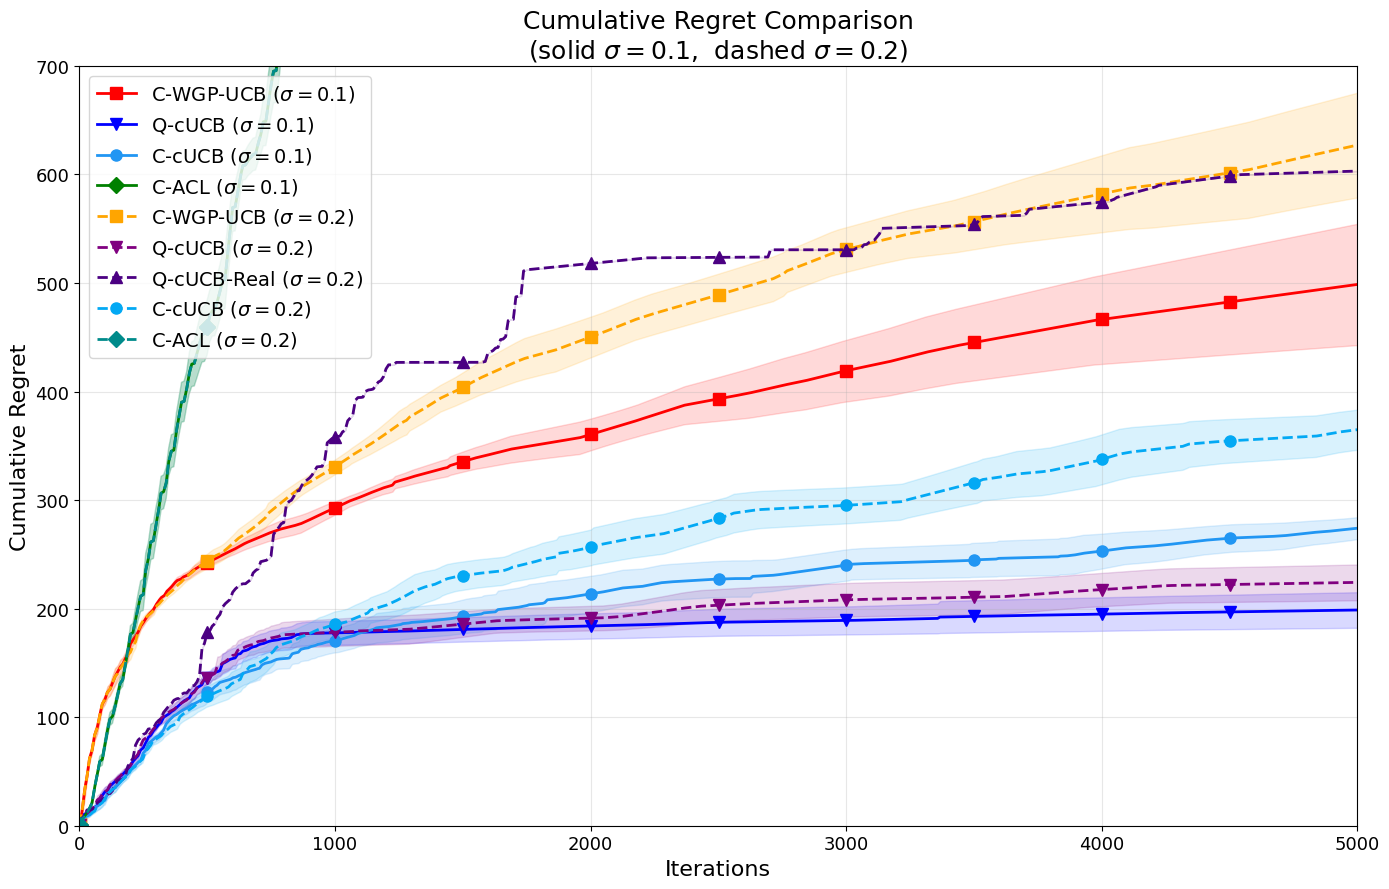

Saved cumulative_regret_comparison.png


In [8]:
# ---- Single combined plot: all methods x both noise levels ----

linestyle_map = {
    0.1**2: '-',    # solid  for sigma=0.1
    0.2**2: '--',   # dashed for sigma=0.2
}

fig, ax = plt.subplots(figsize=(14, 9))

for noise in noise_levels:
    sigma = np.sqrt(noise)
    ls    = linestyle_map[noise]

    for mname, cfg in methods.items():
        if mname not in results[noise]:
            continue
        d    = results[noise][mname]
        end  = min(d['min_len'], X_LIM)
        inds = np.arange(1, end + 1)
        plot_mean_and_CI(
            ax, inds,
            d['mean'][:end], d['lb'][:end], d['ub'][:end],
            color=cfg['colors'][noise], marker=cfg['marker'],
            linestyle=ls,
            label=f"{mname} ($\\sigma={sigma:.1f}$)")

ax.legend(prop={'size': 14}, loc='upper left')
ax.set_xlim([0, X_LIM])
ax.set_ylim([0, 700])
ax.set_xlabel('Iterations', fontsize=16)
ax.set_ylabel('Cumulative Regret', fontsize=16)
ax.set_title('Cumulative Regret Comparison\n'
             '(solid $\\sigma=0.1$,  dashed $\\sigma=0.2$)',
             fontsize=18)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig('cumulative_regret_comparison.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved cumulative_regret_comparison.png')

In [9]:
# ---- Calculate and Display Statistics ----
import numpy as np
from joblib import load
import torch
import os

MAX_BUDGET = 5000
print(f"=== Safe Points Rate & Running Minimum (first {MAX_BUDGET} queried points) ===")
try:
    tsai_wu = load('surrogate_tsaiwu.joblib')
except Exception as e:
    tsai_wu = None
    print(f"[WARN] Could not load Tsai-Wu model: {e}")

if tsai_wu is not None:
    for noise in noise_levels:
        noise_str = str(noise)
        sigma = np.sqrt(noise)
        print(f"\n-- Noise Level $\sigma={sigma:.1f}$ --")

        for mname, cfg in methods.items():
            safe_rates  = []
            best_feass  = []
            total_safe  = 0
            total_points = 0

            for trial in run_list:
                fpath = os.path.join(cfg['dir'], cfg['pattern'].format(noise=noise_str, trial=trial))
                if not os.path.exists(fpath):
                    continue
                try:
                    data = torch.load(fpath, map_location='cpu', weights_only=False)

                    actions_all   = data['actions'].cpu().numpy()
                    true_resp_all = data['true_response'].cpu().numpy().flatten()

                    # Use the shorter of the two arrays as the reference length.
                    # actions and true_response can differ in length (e.g. Q-cUCB
                    # stores all candidate actions but fewer actual evaluations).
                    n_points = min(len(actions_all), len(true_resp_all))
                    cap      = min(n_points, MAX_BUDGET)
                    if cap == 0:
                        continue

                    actions    = actions_all[:cap]
                    true_resps = true_resp_all[:cap]

                    FI    = tsai_wu.predict(actions, return_std=False)
                    c_val = 1.0 - FI

                    num_safe = int(np.sum(c_val >= 0))
                    num_tot  = cap
                    safe_rates.append(num_safe / num_tot)
                    total_safe   += num_safe
                    total_points += num_tot

                    feas_idx = np.where(c_val >= 0)[0]
                    if len(feas_idx) > 0:
                        best_feass.append(float(np.min(true_resps[feas_idx])))
                except Exception as exc:
                    print(f"  [WARN] {fpath}: {exc}")

            if safe_rates:
                avg_rate   = np.mean(safe_rates)
                std_rate   = np.std(safe_rates)
                total_rate = total_safe / total_points if total_points > 0 else 0
                min_str    = (f" | Min: {np.mean(best_feass):.4f} ± {np.std(best_feass):.4f}"
                              if best_feass else " | Min: N/A")
                print(f"  {mname:16s} : {total_safe:5d} / {total_points:5d}  ({total_rate:.2%})"
                      f"   [Per seed: {avg_rate:.2%} ± {std_rate:.2%}]{min_str}")
            else:
                print(f"  {mname:16s} : N/A")

print(f"\n=== Cumulative Regret at iteration/budget = {MAX_BUDGET} ===")
for noise in noise_levels:
    sigma = np.sqrt(noise)
    print(f"\n-- Noise Level $\sigma={sigma:.1f}$ --")
    for mname in methods.keys():
        if mname in results[noise]:
            d = results[noise][mname]
            # Clamp to actual array length if method has fewer queries than MAX_BUDGET
            idx = min(MAX_BUDGET, len(d['mean']) - 1)
            final_mean = d['mean'][idx]
            final_std  = d['ub'][idx] - d['mean'][idx]
            note = f" (at step {idx})" if idx < MAX_BUDGET else ""
            print(f"  {mname:16s} : {final_mean:8.2f} ± {final_std:<8.2f}{note}")


=== Safe Points Rate & Running Minimum (first 5000 queried points) ===

-- Noise Level $\sigma=0.1$ --
  C-WGP-UCB        :   177 /   275  (64.36%)   [Per seed: 63.78% ± 11.67%] | Min: 0.0785 ± 0.0468
  Q-cUCB           :   473 /   473  (100.00%)   [Per seed: 100.00% ± 0.00%] | Min: 0.0485 ± 0.0006
  Q-cUCB-Real      : N/A
  C-cUCB           :   411 /   411  (100.00%)   [Per seed: 100.00% ± 0.00%] | Min: 0.0485 ± 0.0006
  C-ACL            :  1386 /  2505  (55.33%)   [Per seed: 55.33% ± 9.65%] | Min: 0.0597 ± 0.0108

-- Noise Level $\sigma=0.2$ --
  C-WGP-UCB        :   168 /   252  (66.67%)   [Per seed: 66.79% ± 2.46%] | Min: 0.0649 ± 0.0268
  Q-cUCB           :   434 /   434  (100.00%)   [Per seed: 100.00% ± 0.00%] | Min: 0.0492 ± 0.0013
  Q-cUCB-Real      :   185 /   185  (100.00%)   [Per seed: 100.00% ± 0.00%] | Min: 0.0482 ± 0.0000
  C-cUCB           :   347 /   347  (100.00%)   [Per seed: 100.00% ± 0.00%] | Min: 0.0488 ± 0.0008
  C-ACL            :  1386 /  2505  (55.33%)   [Per s

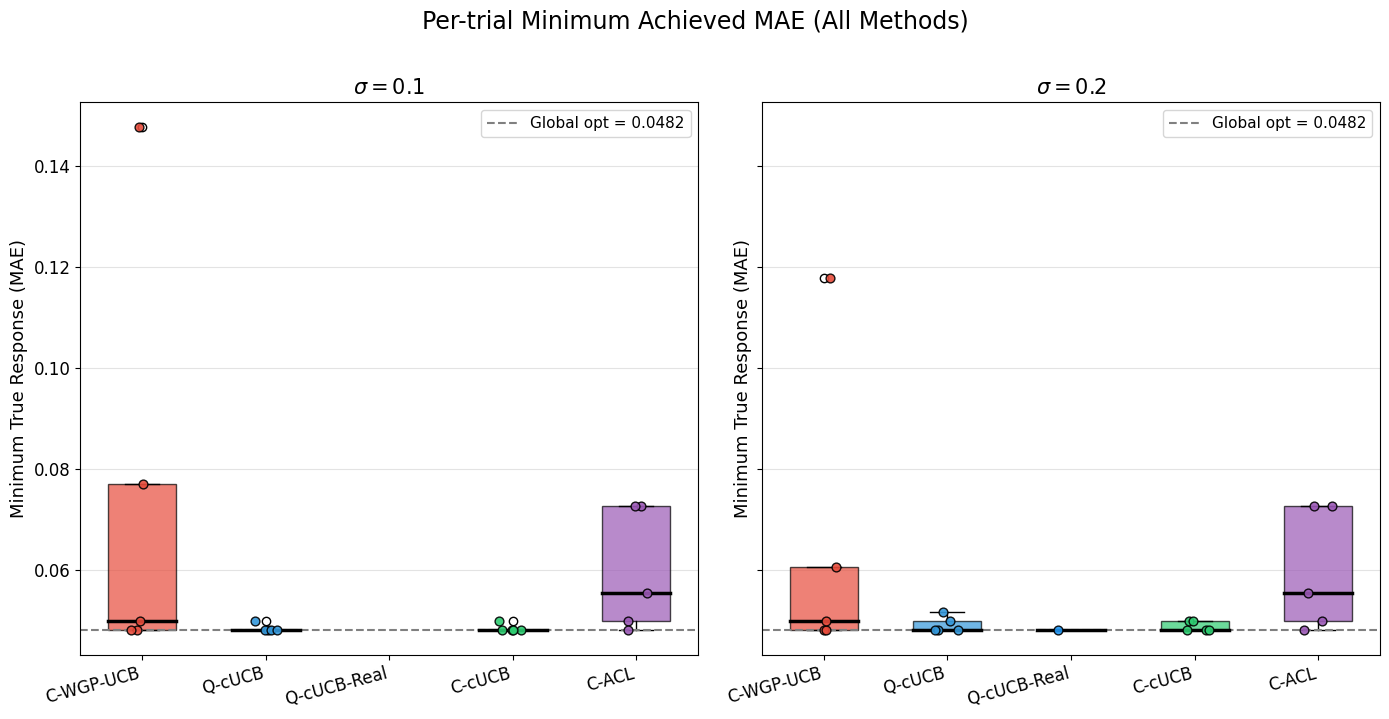

Saved boxplot_min_response_all.png


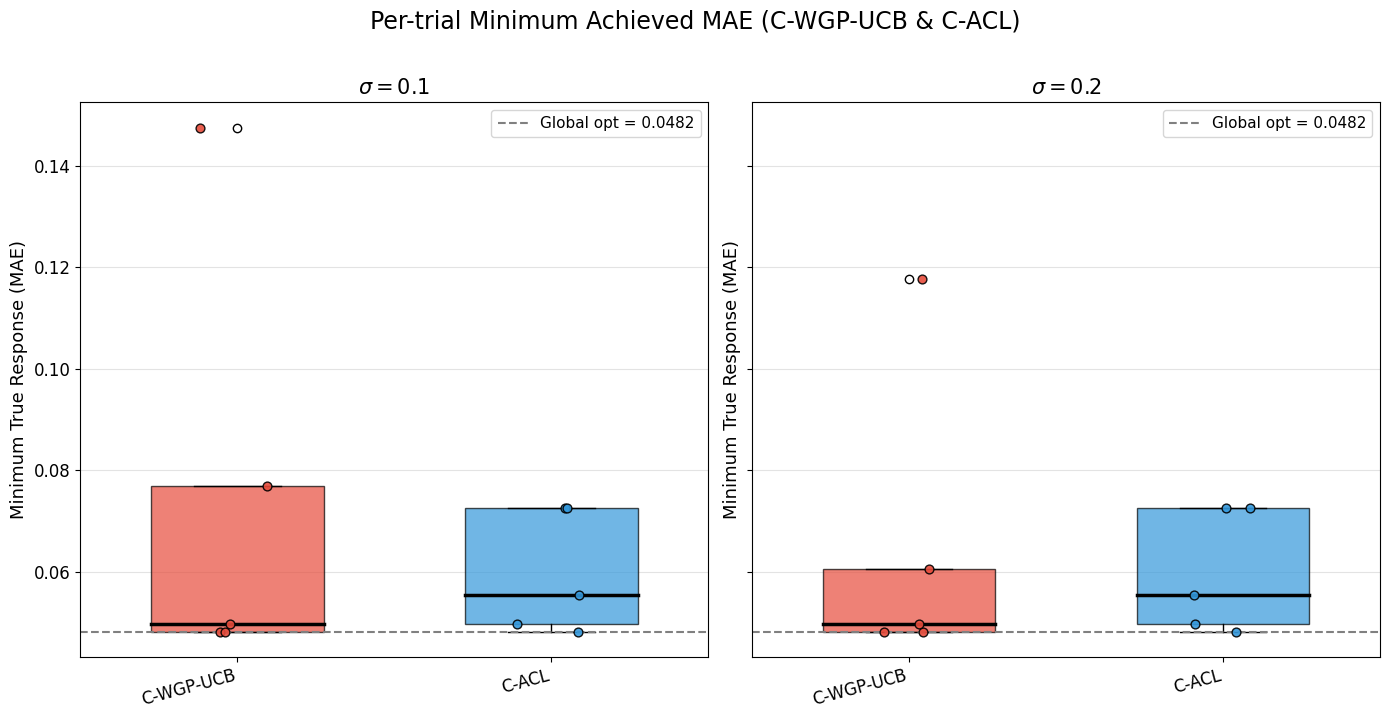

Saved boxplot_min_response_other.png


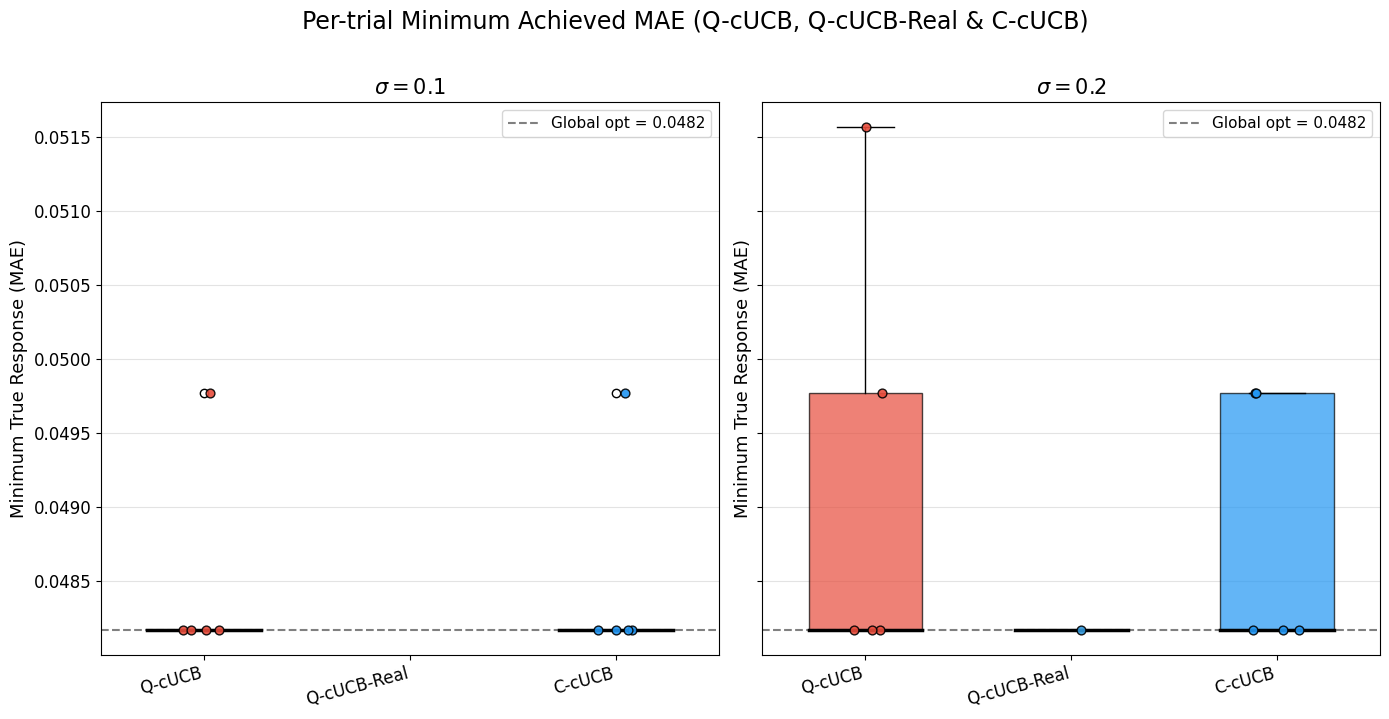

Saved boxplot_min_response_qcucb.png


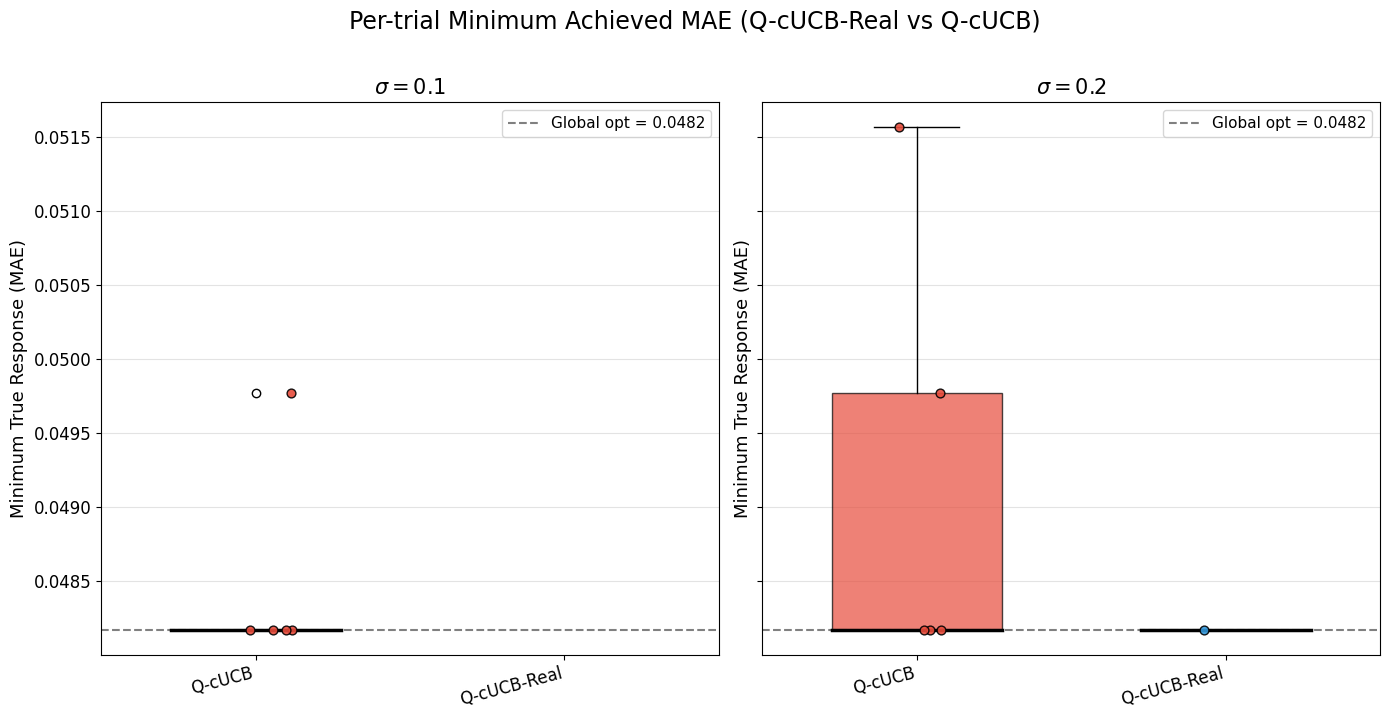

Saved boxplot_min_response_real_vs_sim.png


In [10]:
# ---- Boxplot: minimum true_response per trial per method ----
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

def render_boxplot(method_subset, title_suffix, filename):
    fig, axes = plt.subplots(1, len(noise_levels), figsize=(7 * len(noise_levels), 7), sharey=True)
    if len(noise_levels) == 1:
        axes = [axes]
    
    # Filter methods and assign colors
    my_methods = {k: methods[k] for k in method_subset if k in methods}
    method_names = list(my_methods.keys())
    
    # A generic color palette for whichever methods are passed
    palette = ['#e74c3c', '#3498db', '#2196F3', '#2ecc71', '#9b59b6', '#f1c40f']
    colors = palette[:len(method_names)]
    
    positions_base = np.arange(len(method_names))
    width = 0.55

    for ax_idx, noise in enumerate(noise_levels):
        noise_str = str(noise)
        sigma = np.sqrt(noise)
        ax = axes[ax_idx]

        box_data   = []   # list of arrays, one per method
        box_labels = []

        for m_idx, (mname, cfg) in enumerate(my_methods.items()):
            trial_mins = []
            for trial in run_list:
                fpath = os.path.join(cfg['dir'],
                                     cfg['pattern'].format(noise=noise_str, trial=trial))
                if not os.path.exists(fpath):
                    continue
                try:
                    data = torch.load(fpath, map_location='cpu', weights_only=False)
                    tr = data['true_response'].cpu().numpy().flatten()
                    if len(tr) > 0:
                        trial_mins.append(float(np.min(tr)))
                except Exception as exc:
                    print(f"[WARN] {fpath}: {exc}")

            box_data.append(trial_mins if trial_mins else [float('nan')])
            box_labels.append(mname)

        # Draw boxplots
        bp = ax.boxplot(box_data,
                        positions=positions_base,
                        widths=width,
                        patch_artist=True,
                        showfliers=True,
                        medianprops=dict(color='black', linewidth=2.5))

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Overlay individual trial points (jittered)
        for m_idx, vals in enumerate(box_data):
            if all(np.isnan(v) for v in vals):
                continue
            jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(positions_base[m_idx] + jitter, vals,
                       color=colors[m_idx], edgecolor='black',
                       zorder=5, s=40, alpha=0.9)

        # Reference line: global optimum
        ax.axhline(f_max, color='grey', linestyle='--', linewidth=1.5,
                   label=f'Global opt = {f_max:.4f}')

        ax.set_xticks(positions_base)
        ax.set_xticklabels(box_labels, fontsize=13, rotation=15, ha='right')
        ax.set_title(f'$\\sigma = {sigma:.1f}$', fontsize=15)
        ax.set_ylabel('Minimum True Response (MAE)', fontsize=13)
        ax.legend(fontsize=11, loc='upper right')
        ax.grid(axis='y', alpha=0.35)
        ax.tick_params(labelsize=12)

    fig.suptitle(f'Per-trial Minimum Achieved MAE {title_suffix}', fontsize=17, y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {filename}")

# Plot 1: All Methods
render_boxplot(list(methods.keys()), "(All Methods)", 'boxplot_min_response_all.png')

# Plot 2: C-WGP-UCB and C-ACL (The other methods)
render_boxplot(['C-WGP-UCB', 'C-ACL'], "(C-WGP-UCB & C-ACL)", 'boxplot_min_response_other.png')

# Plot 3: Q-cUCB and C-cUCB Separate
render_boxplot(['Q-cUCB', 'Q-cUCB-Real', 'C-cUCB'], "(Q-cUCB, Q-cUCB-Real & C-cUCB)", 'boxplot_min_response_qcucb.png')

# Plot 4: Q-cUCB-Real vs Q-cUCB
render_boxplot(['Q-cUCB', 'Q-cUCB-Real'], "(Q-cUCB-Real vs Q-cUCB)", 'boxplot_min_response_real_vs_sim.png')


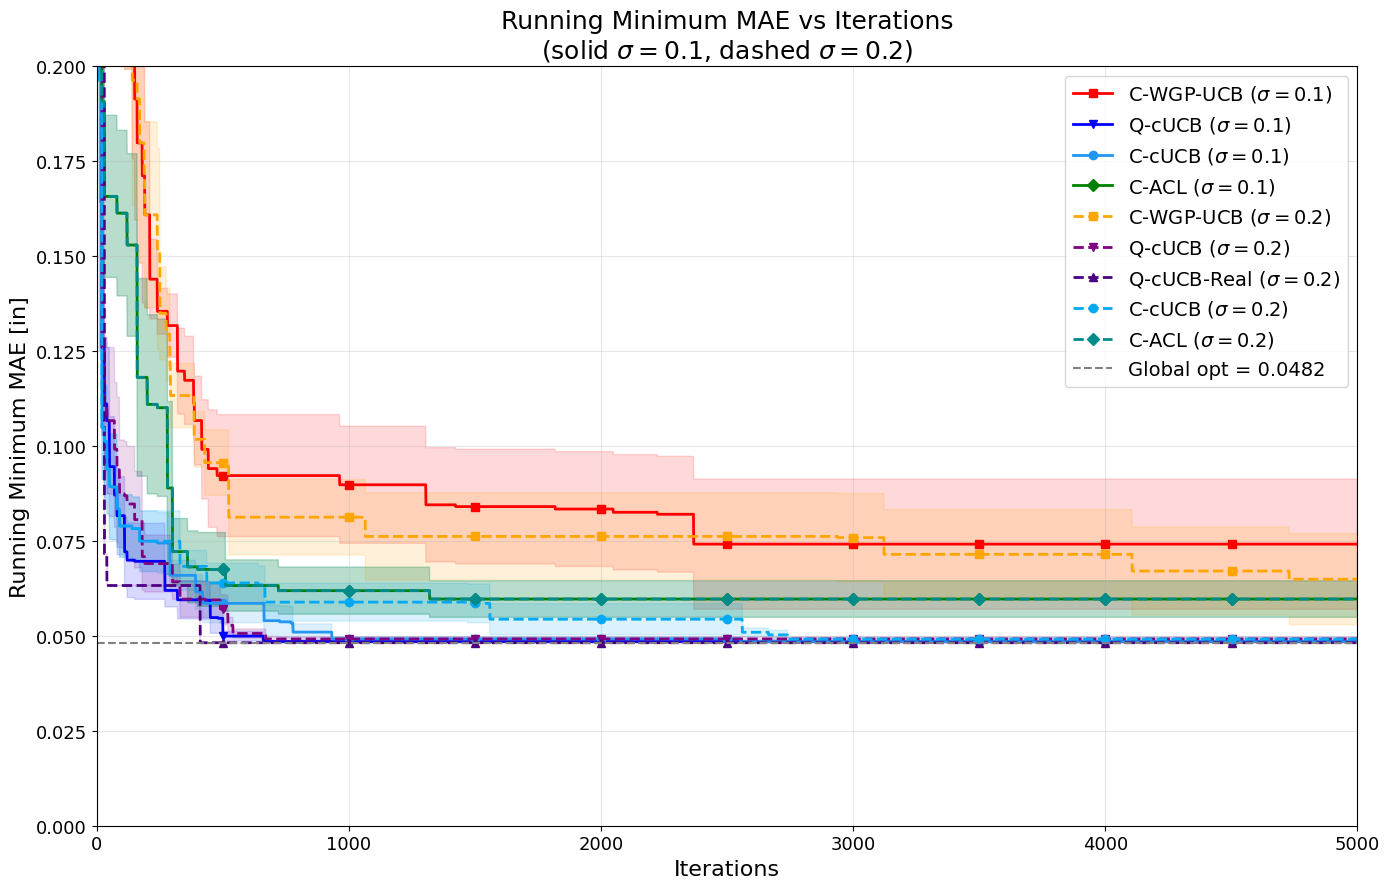

Saved running_minimum_comparison.png


In [11]:
# ---- Running Minimum vs Iterations ----
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

fig, ax = plt.subplots(figsize=(14, 9))

linestyle_map = {
    0.1**2: '-',    # solid  for sigma=0.1
    0.2**2: '--',   # dashed for sigma=0.2
}

for noise in noise_levels:
    noise_str = str(noise)
    sigma = np.sqrt(noise)
    ls = linestyle_map[noise]

    for mname, cfg in methods.items():
        all_runmins = []
        min_len = MAX_BUDGET
        
        for trial in run_list:
            fpath = os.path.join(cfg['dir'],
                                 cfg['pattern'].format(noise=noise_str, trial=trial))
            if not os.path.exists(fpath):
                continue

            try:
                data = torch.load(fpath, map_location=device, weights_only=False)
                true_response = data['true_response'].to(torch.float32).to(device)
                num_of_queries = data['queries']
                
                vals = true_response.detach().cpu().numpy().reshape(-1)
                track = num_of_queries.detach().cpu().numpy().astype(np.int32).reshape(-1)
                track = np.where(track <= 0, 1, track)  # clamp 0-query entries to 1
                
                expanded_vals = []
                for i in range(len(vals)):
                    expanded_vals += list(np.repeat(vals[i], track[i]))
                expanded_vals = np.array(expanded_vals)
                
                runmin = np.minimum.accumulate(expanded_vals)
                min_len = min(min_len, len(runmin))
                all_runmins.append(runmin)
            except Exception as exc:
                print(f"[WARN] {fpath}: {exc}")

        if all_runmins:
            all_runmins = [a[:min_len] for a in all_runmins]
            arr = np.array(all_runmins)
            mean = arr.mean(axis=0)
            stderr = arr.std(axis=0) / np.sqrt(len(all_runmins))
            
            end = min(min_len, X_LIM)
            iters = np.arange(1, end + 1)
            
            color = cfg['colors'][noise]
            ax.fill_between(iters, mean[:end] - stderr[:end], mean[:end] + stderr[:end],
                            alpha=0.15, color=color)
            ax.plot(iters, mean[:end], label=f"{mname} ($\\sigma={sigma:.1f}$)", color=color, 
                    linestyle=ls, linewidth=2, marker=cfg['marker'], markevery=500)

ax.axhline(f_max, color='grey', linestyle='--', linewidth=1.5,
           label=f'Global opt = {f_max:.4f}')

ax.legend(prop={'size': 14}, loc='upper right')
ax.set_xlim([0, X_LIM])
ax.set_ylim([0.0, 0.2])
ax.set_xlabel('Iterations', fontsize=16)
ax.set_ylabel('Running Minimum MAE [in]', fontsize=16)
ax.set_title('Running Minimum MAE vs Iterations\n(solid $\\sigma=0.1$, dashed $\\sigma=0.2$)', fontsize=18)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig('running_minimum_comparison.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved running_minimum_comparison.png')
